# 09 - Quality Assurance Dashboard: Customer Complaints, Supplier Quality, NC & CAPA

**Stage 5, continued.**

This notebook builds the indicators for a Quality Assurance dashboard
that sits alongside the production/quality/maintenance ones from
notebooks 05-07: how customers experience the product after it ships,
how well incoming raw material meets specification, and how the plant's
formal non-conformance and CAPA system is performing.

Three parts: **Customer Complaints**, **Supplier Quality**, and
**Non-Conformance & CAPA**.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

PROCESSED = '../../datasets/processed'
REPORTS = '../../reports'
import os
os.makedirs(REPORTS, exist_ok=True)

dim_customer = pd.read_csv(f'{PROCESSED}/dim_customer.csv', encoding='utf-8-sig')
dim_supplier = pd.read_csv(f'{PROCESSED}/dim_supplier.csv', encoding='utf-8-sig')

sales = pd.read_csv(f'{PROCESSED}/fact_sales_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
complaints = pd.read_csv(f'{PROCESSED}/fact_customer_complaints_processed.csv', encoding='utf-8-sig', parse_dates=['Date', 'ResolutionDate'])
rm_inspection = pd.read_csv(f'{PROCESSED}/fact_raw_material_inspection_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
rm_disposition = pd.read_csv(f'{PROCESSED}/fact_raw_material_lot_disposition_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
supplier_complaints = pd.read_csv(f'{PROCESSED}/fact_supplier_complaints_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
nonconformance = pd.read_csv(f'{PROCESSED}/fact_nonconformance_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
capa = pd.read_csv(f'{PROCESSED}/fact_capa_processed.csv', encoding='utf-8-sig', parse_dates=['OpenDate', 'DueDate', 'CloseDate'])

complaints = complaints.merge(dim_customer[['CustomerId', 'CustomerName', 'Segment', 'City']], on='CustomerId', how='left')
print("Loaded.")


Loaded.


# Part 1 - Customer Complaints


## 1.1 Number of Customer Complaints (overall + by severity)


Total complaints: 397


Severity
Critical    154
Major       128
Minor       115
Name: count, dtype: int64

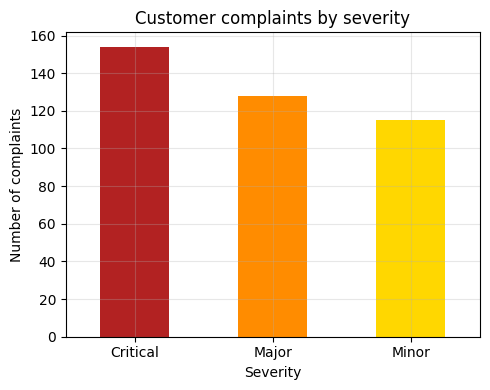

In [2]:
print(f"Total complaints: {len(complaints):,}")
display(complaints['Severity'].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
complaints['Severity'].value_counts().reindex(['Critical', 'Major', 'Minor']).plot(
    kind='bar', color=['firebrick', 'darkorange', 'gold'], ax=ax)
ax.set_ylabel('Number of complaints')
ax.set_title('Customer complaints by severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/21_complaints_by_severity.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.2 Complaints by Customer


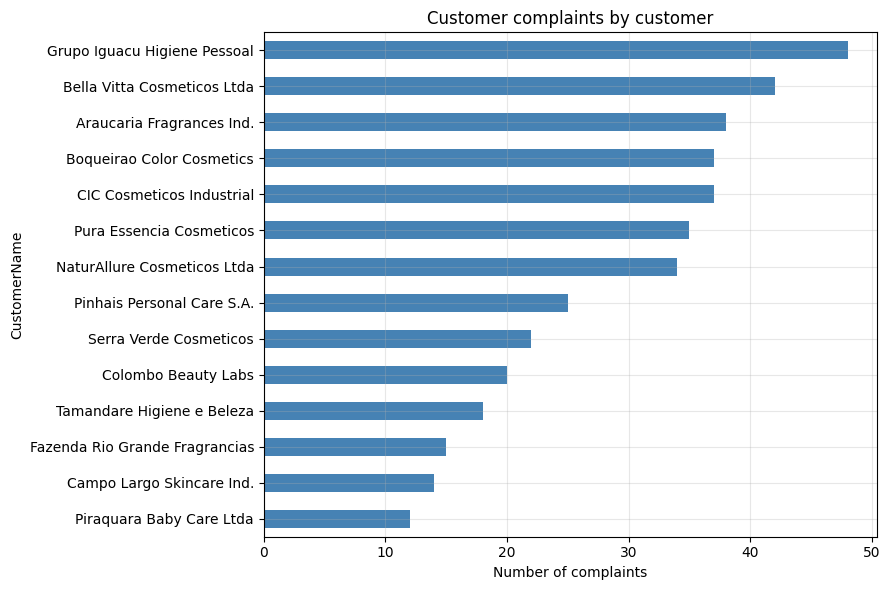

In [3]:
by_customer = complaints.groupby('CustomerName').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
by_customer.plot(kind='barh', color='steelblue', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of complaints')
ax.set_title('Customer complaints by customer')
plt.tight_layout()
plt.savefig(f'{REPORTS}/22_complaints_by_customer.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.3 Complaints by Product / by Family


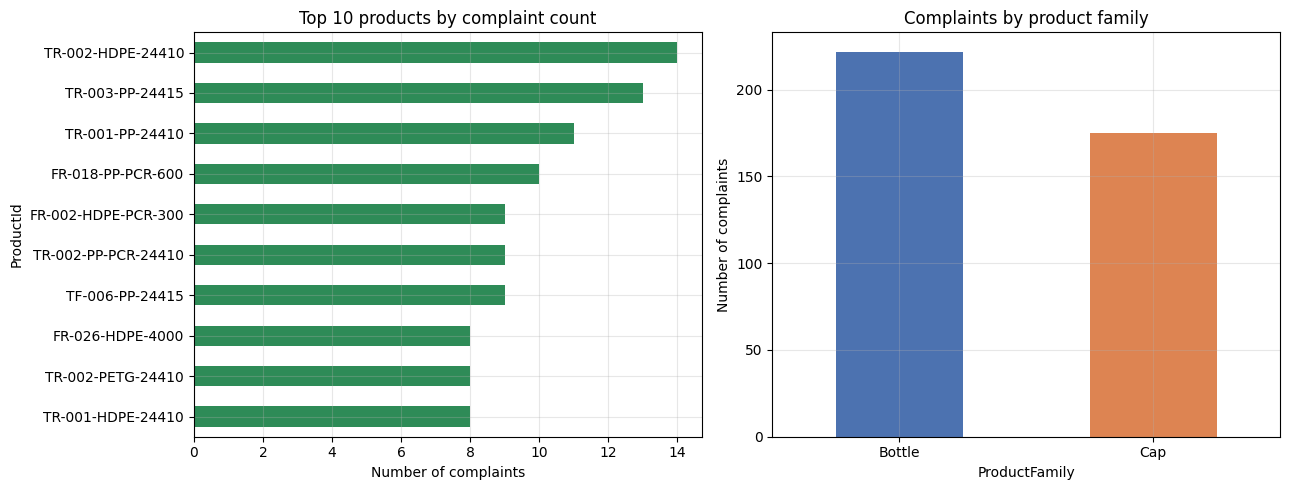

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

complaints.groupby('ProductId').size().sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 products by complaint count')
axes[0].set_xlabel('Number of complaints')

complaints.groupby('ProductFamily').size().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Complaints by product family')
axes[1].set_ylabel('Number of complaints')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/23_complaints_by_product_and_family.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.4 Complaints by Defect Type


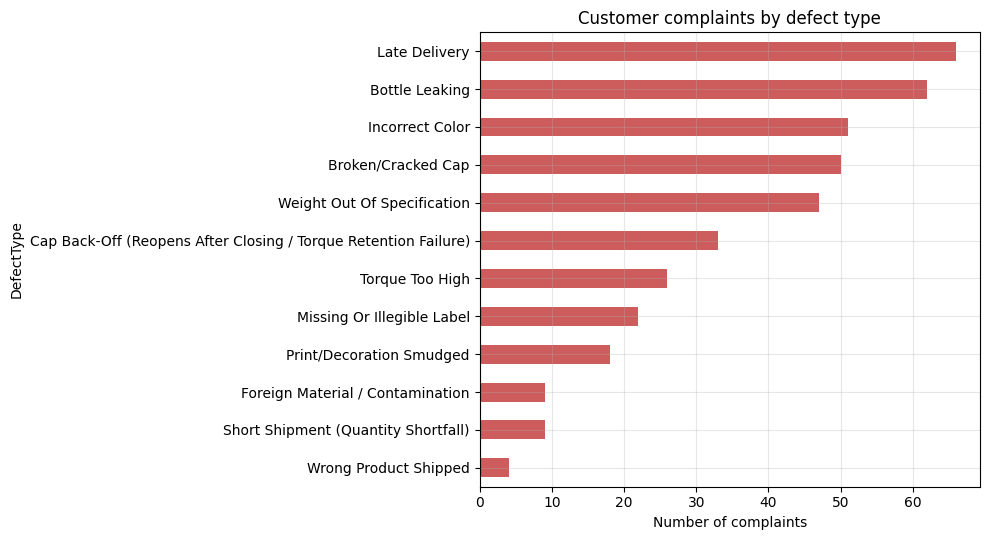

In [5]:
by_defect = complaints.groupby('DefectType').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
by_defect.plot(kind='barh', color='indianred', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of complaints')
ax.set_title('Customer complaints by defect type')
plt.tight_layout()
plt.savefig(f'{REPORTS}/24_complaints_by_defect_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.5 Monthly Trend


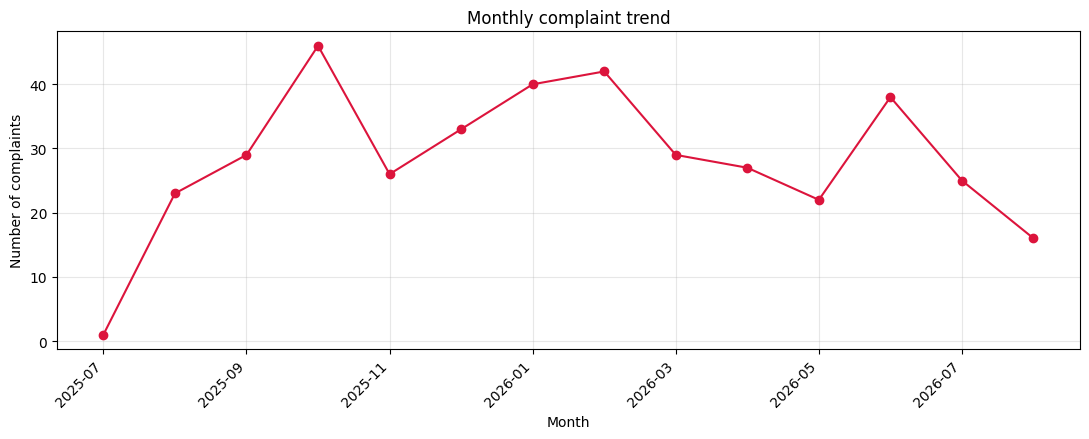

In [6]:
monthly = complaints.groupby('Month').size()

fig, ax = plt.subplots(figsize=(11, 4.5))
monthly.plot(kind='line', marker='o', color='crimson', ax=ax)
ax.set_ylabel('Number of complaints')
ax.set_xlabel('Month')
ax.set_title('Monthly complaint trend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{REPORTS}/25_complaints_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.6 Complaints per Million Units Shipped (CPMU)

The normalized version of "how many complaints" -- comparing raw counts
across customers or products that ship very different volumes is
misleading; CPMU puts them on the same scale. Uses
`etl_lib.complaints_per_million_shipped`.


Plant-wide CPMU: 6.6 complaints per million units shipped


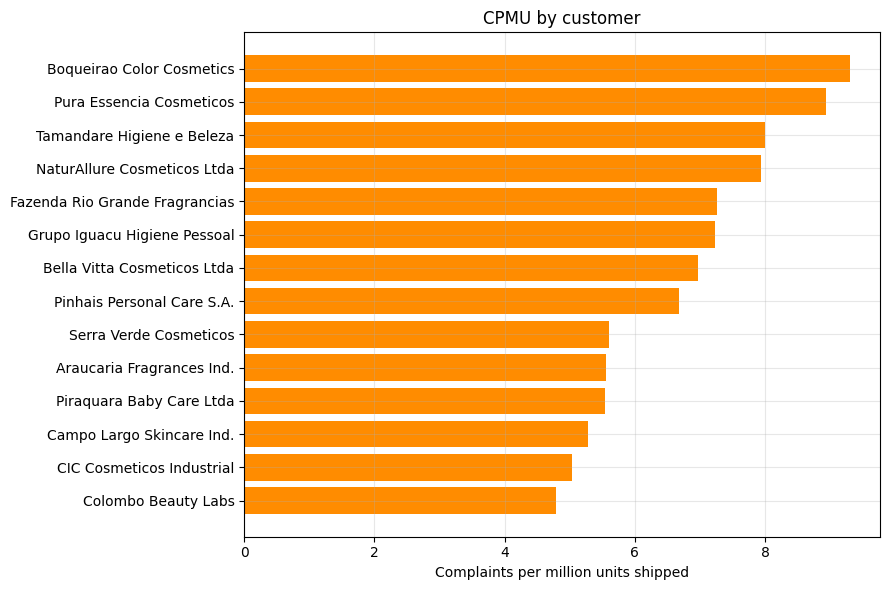

In [7]:
import etl_lib as etl

overall_cpmu = etl.complaints_per_million_shipped(complaints, sales)
print(f"Plant-wide CPMU: {overall_cpmu.iloc[0]:.1f} complaints per million units shipped")

cpmu_by_customer = etl.complaints_per_million_shipped(
    complaints.rename(columns={'CustomerId': 'CustomerId'}), sales, group_cols=['CustomerId']
).sort_values(ascending=False)
cpmu_by_customer = cpmu_by_customer.to_frame().join(dim_customer.set_index('CustomerId')[['CustomerName']])

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cpmu_by_customer['CustomerName'], cpmu_by_customer['ComplaintsPerMillionShipped'], color='darkorange')
ax.invert_yaxis()
ax.set_xlabel('Complaints per million units shipped')
ax.set_title('CPMU by customer')
plt.tight_layout()
plt.savefig(f'{REPORTS}/26_cpmu_by_customer.png', dpi=150, bbox_inches='tight')
plt.show()


# Part 2 - Supplier Quality


## 2.1 Complaints to Supplier (Reclamações ao Fornecedor)


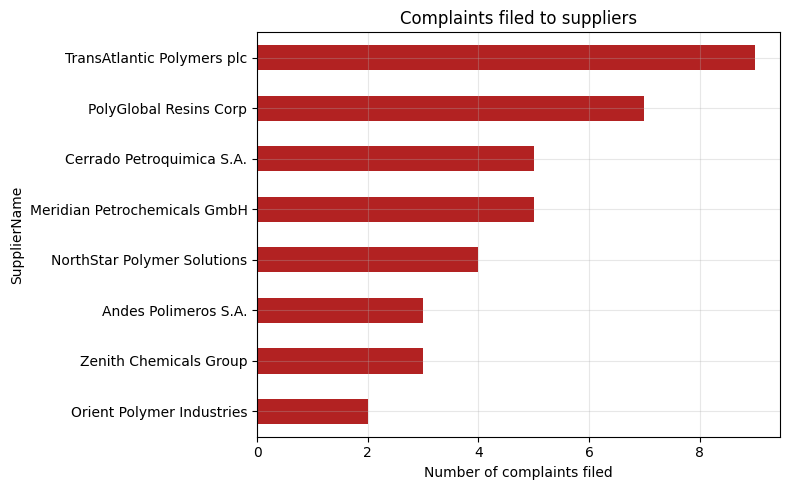

By issue type:


IssueType
Off-Spec Test Result                 15
Short Shipment                        7
Documentation Error / Missing Coa     7
Packaging Damaged In Transit          4
Late Delivery Of Po                   2
Wrong Material Supplied               2
Contamination                         1
Name: count, dtype: int64

In [8]:
sc_by_supplier = supplier_complaints.merge(dim_supplier[['SupplierId', 'SupplierName']], on='SupplierId').groupby('SupplierName').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sc_by_supplier.plot(kind='barh', color='firebrick', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of complaints filed')
ax.set_title('Complaints filed to suppliers')
plt.tight_layout()
plt.savefig(f'{REPORTS}/27_complaints_to_supplier.png', dpi=150, bbox_inches='tight')
plt.show()

print("By issue type:")
display(supplier_complaints['IssueType'].value_counts())


## 2.2 Rejected Raw Material (Matéria-Prima Rejeitada)


Rejected lots: 3 of 1193 (0.25%)
Rejected quantity: 46,766 kg


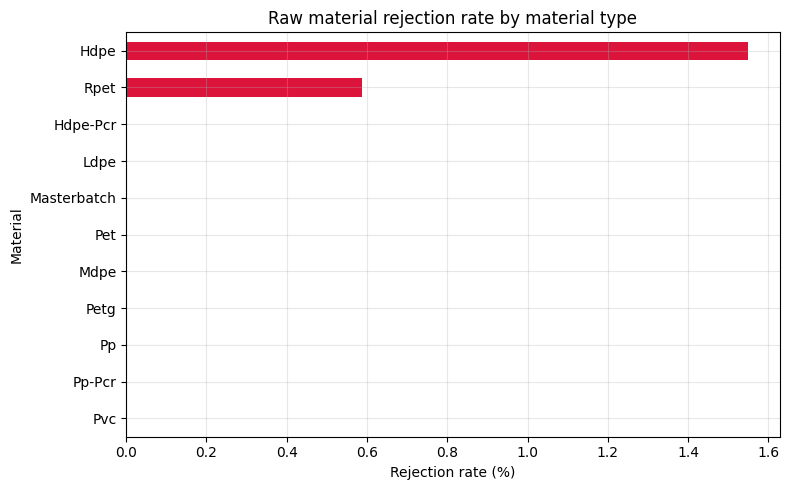

In [9]:
rejected = rm_disposition[rm_disposition['FinalDecision'] == 'Rejected']
print(f"Rejected lots: {len(rejected)} of {len(rm_disposition)} ({len(rejected)/len(rm_disposition):.2%})")
print(f"Rejected quantity: {rejected['ReceivedQtyKg']:,.0f} kg".replace(',', ' ') if False else f"Rejected quantity: {rejected['ReceivedQtyKg'].sum():,.0f} kg")

rejected_by_material = rm_disposition.groupby('Material')['FinalDecision'].apply(lambda s: (s == 'Rejected').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
rejected_by_material.plot(kind='barh', color='crimson', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Rejection rate (%)')
ax.set_title('Raw material rejection rate by material type')
plt.tight_layout()
plt.savefig(f'{REPORTS}/28_rejected_raw_material_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.3 Supplier Approval Rate (Índice de Aprovação do Fornecedor)

Uses `etl_lib.supplier_approval_rate` -- the share of a supplier's
incoming lots that were Accepted outright (vs. Accepted with Deviation or
Rejected).


,SupplierName,ApprovalRatePct
SupplierId,,
SUP-007,Cerrado Petroquimica S.A.,93.4
SUP-002,Meridian Petrochemicals GmbH,94.0
SUP-004,TransAtlantic Polymers plc,94.2
SUP-006,Zenith Chemicals Group,94.3
SUP-001,PolyGlobal Resins Corp,95.4
SUP-008,Andes Polimeros S.A.,96.0
SUP-003,NorthStar Polymer Solutions,96.9
SUP-005,Orient Polymer Industries,97.6


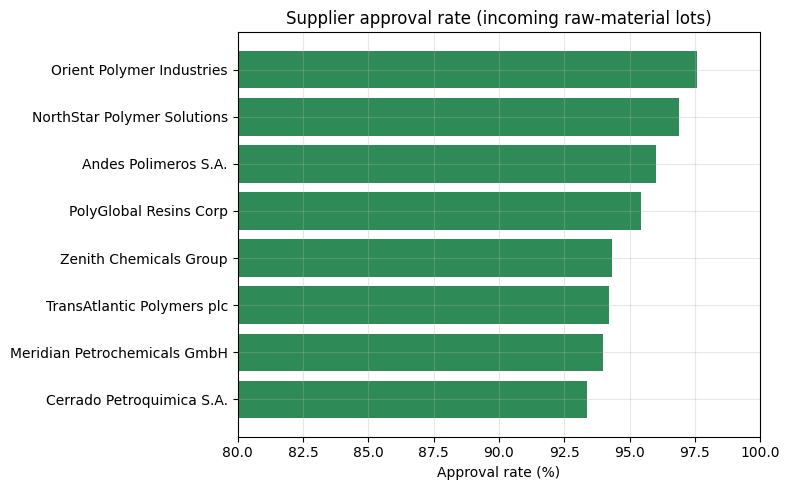

In [10]:
approval = etl.supplier_approval_rate(rm_disposition).join(dim_supplier.set_index('SupplierId')[['SupplierName']])
approval = approval.sort_values('ApprovalRatePct')
display(approval[['SupplierName', 'ApprovalRatePct']].round(1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(approval['SupplierName'], approval['ApprovalRatePct'], color='seagreen')
ax.set_xlim(80, 100)
ax.set_xlabel('Approval rate (%)')
ax.set_title('Supplier approval rate (incoming raw-material lots)')
plt.tight_layout()
plt.savefig(f'{REPORTS}/29_supplier_approval_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.4 Average Response Time (Tempo Médio para Resposta)


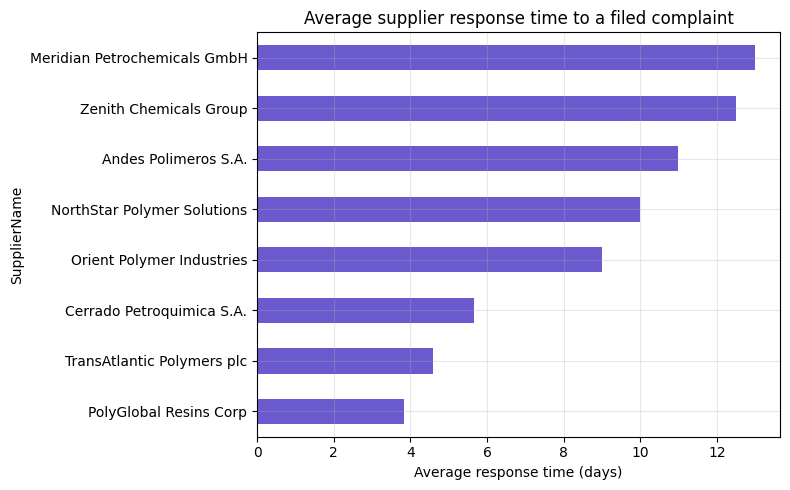

Plant-wide average response time: 7.0 days


In [11]:
response_time = supplier_complaints.merge(dim_supplier[['SupplierId', 'SupplierName']], on='SupplierId').groupby('SupplierName')['ResponseDays'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
response_time.plot(kind='barh', color='slateblue', ax=ax)
ax.set_xlabel('Average response time (days)')
ax.set_title('Average supplier response time to a filed complaint')
plt.tight_layout()
plt.savefig(f'{REPORTS}/30_supplier_response_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plant-wide average response time: {supplier_complaints['ResponseDays'].mean():.1f} days")


# Part 3 - Non-Conformance & CAPA


## 3.1 Internal vs. External NC


Type
External    304
Internal    208
Name: count, dtype: int64


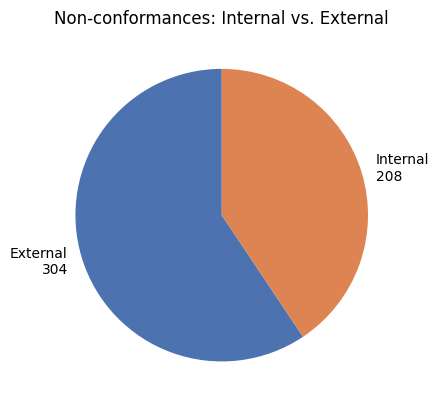

In [12]:
nc_type = nonconformance['Type'].value_counts()
print(nc_type)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.pie(nc_type.values, labels=[f"{i}\n{v}" for i, v in nc_type.items()], colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Non-conformances: Internal vs. External')
plt.tight_layout()
plt.savefig(f'{REPORTS}/31_nc_internal_vs_external.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.2 NC by Process and by Area


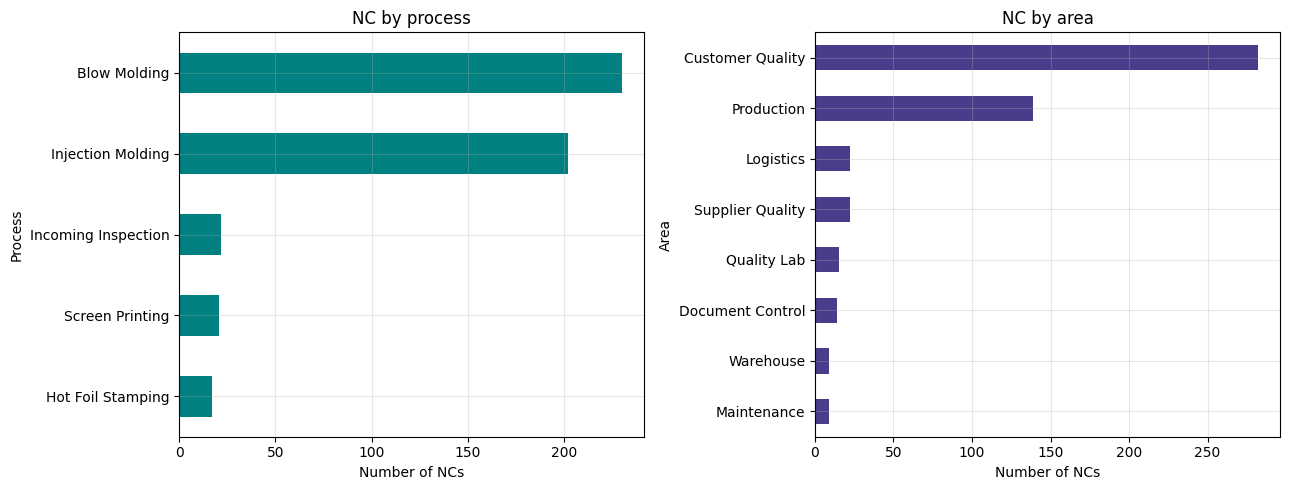

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nonconformance.groupby('Process').size().sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('NC by process')
axes[0].set_xlabel('Number of NCs')

nonconformance.groupby('Area').size().sort_values().plot(kind='barh', ax=axes[1], color='darkslateblue')
axes[1].set_title('NC by area')
axes[1].set_xlabel('Number of NCs')
plt.tight_layout()
plt.savefig(f'{REPORTS}/32_nc_by_process_and_area.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.3 CAPA: Open, Closed, Overdue


Status
Closed     243
Overdue     93
Open        21
Name: count, dtype: int64

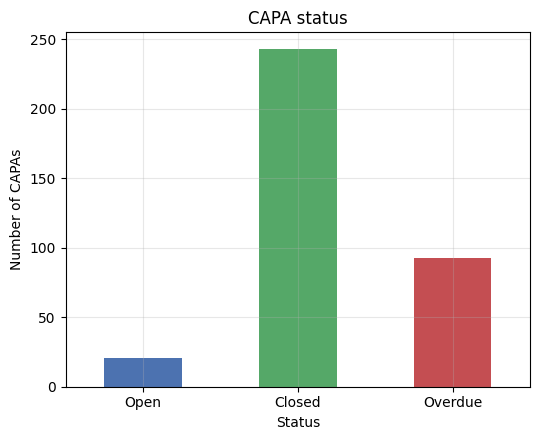

In [14]:
capa_status = capa['Status'].value_counts()
display(capa_status)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
capa_status.reindex(['Open', 'Closed', 'Overdue']).plot(
    kind='bar', color=['#4C72B0', '#55A868', '#C44E52'], ax=ax)
ax.set_ylabel('Number of CAPAs')
ax.set_title('CAPA status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/33_capa_status.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Average CAPA Closure Time


Average closure time: 46.8 days (n=243)


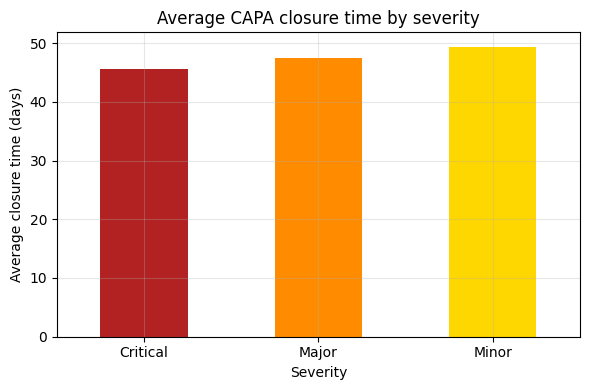

In [15]:
closed_capa = capa[capa['Status'] == 'Closed']
print(f"Average closure time: {closed_capa['ClosureDays'].mean():.1f} days (n={len(closed_capa)})")

closure_by_severity = closed_capa.groupby('Severity')['ClosureDays'].mean().reindex(['Critical', 'Major', 'Minor'])
fig, ax = plt.subplots(figsize=(6, 4))
closure_by_severity.plot(kind='bar', color=['firebrick', 'darkorange', 'gold'], ax=ax)
ax.set_ylabel('Average closure time (days)')
ax.set_title('Average CAPA closure time by severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/34_capa_closure_time_by_severity.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

- Plant-wide complaint rate sits in the low single digits per million
  units shipped -- a healthy benchmark for packaging components -- but
  varies meaningfully by customer and defect type, which is exactly what
  the customer and defect-type breakdowns above are for.
- Supplier approval rates cluster in the low-to-mid 90s%, with real
  separation between suppliers -- enough signal to justify a supplier
  scorecard / business-review conversation with the lower-ranked ones.
- Roughly a quarter of CAPAs are overdue at any point in time in this
  dataset -- the single most actionable number on this page for a QA
  manager, since it is a direct measure of whether the corrective-action
  system itself is keeping up with its own commitments.
